# Detection des contours par Canny

## Description

Canny detecte les contours forts de l'image. Dans ce projet, il sert a valider visuellement les limites de la voiture dans la ROI. Il ne constitue pas la methode principale de tracking: le suivi reste base sur Lucas-Kanade.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


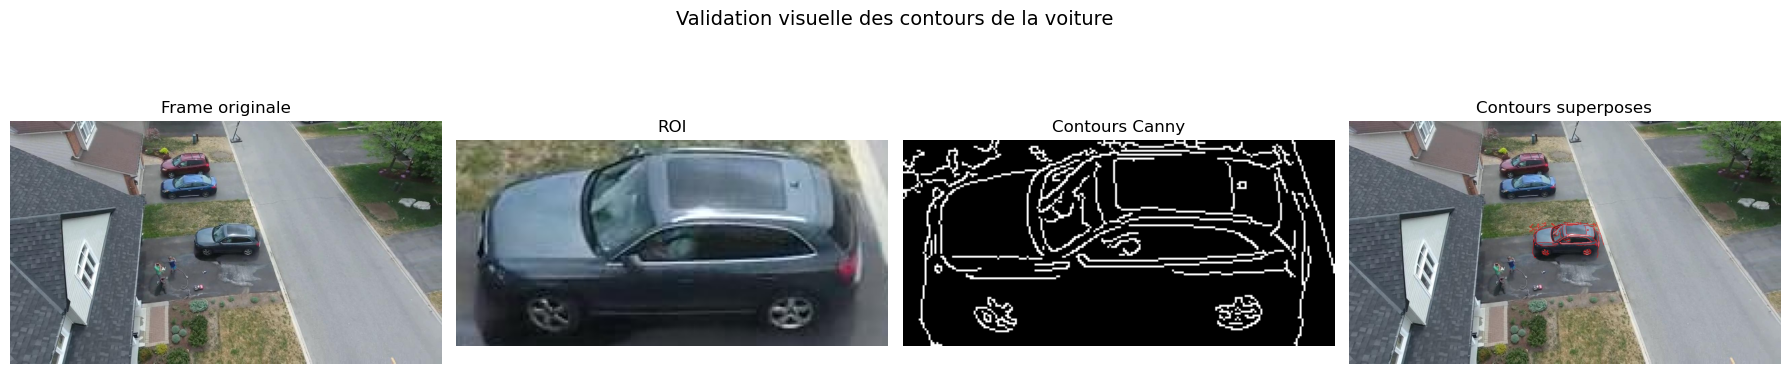

In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def draw_bbox_local(image, bbox, color=(0, 255, 0), thickness=2):
    out = image.copy()
    x, y, w, h = [int(v) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out

def draw_points_local(image, points, color=(0, 0, 255)):
    out = image.copy()
    if points is None:
        return out
    for px, py in np.asarray(points).reshape(-1, 2):
        cv2.circle(out, (int(px), int(py)), 3, color, -1)
    return out

def draw_mask_overlay_local(frame, mask, bbox):
    out = frame.copy()
    overlay = out.copy()
    x, y, w, h = [int(v) for v in bbox]
    mask_roi = mask
    if mask_roi.shape[:2] != (h, w):
        mask_roi = cv2.resize(mask_roi, (w, h), interpolation=cv2.INTER_NEAREST)
    roi = overlay[y:y+h, x:x+w]
    roi[mask_roi > 0] = (0, 255, 0)
    overlay[y:y+h, x:x+w] = roi
    return cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

from src.preprocessing import preprocess_image_with_method
from src.edge_detection import canny_on_roi, overlay_edges_on_frame

edge_dir = ensure_dir(RESULTS_DIR / "edge_detection")
frame = cv2.imread(str(image_files[0]))
gray = preprocess_image_with_method(frame, method="stretching")["enhanced"]
x, y, w, h = initial_bbox
roi_bgr = frame[y:y+h, x:x+w]
edges = canny_on_roi(gray, initial_bbox, low_threshold=50, high_threshold=150)
edge_overlay = overlay_edges_on_frame(frame, edges, bbox=initial_bbox)

save_bgr(edge_dir / "canny_frame_original.png", frame)
save_bgr(edge_dir / "canny_roi.png", roi_bgr)
save_gray(edge_dir / "canny_edges_roi.png", edges)
save_bgr(edge_dir / "canny_overlay.png", edge_overlay)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
items = [("Frame originale", frame, False), ("ROI", roi_bgr, False), ("Contours Canny", edges, True), ("Contours superposes", edge_overlay, False)]
for ax, (title, image, gray_mode) in zip(axes, items):
    ax.imshow(image if gray_mode else bgr_to_rgb(image), cmap="gray" if gray_mode else None)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Validation visuelle des contours de la voiture", fontsize=14)
fig.tight_layout()
fig.savefig(edge_dir / "canny_results_grid.png", dpi=150)
plt.show()


## Interpretation

Les contours Canny mettent en evidence les limites visibles de la voiture et certains details internes. Des contours parasites peuvent apparaitre sur la route, les ombres ou les textures proches. Cette visualisation aide a verifier que la ROI contient bien la voiture avant l'estimation du mouvement.


# Detection du mouvement par difference d'images

## Description

La difference d'images calcule `absdiff` entre deux frames successives. Un seuillage transforme cette difference en motion mask binaire. Cette methode montre les pixels qui changent entre deux instants et permet de confirmer visuellement le mouvement avant Lucas-Kanade.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


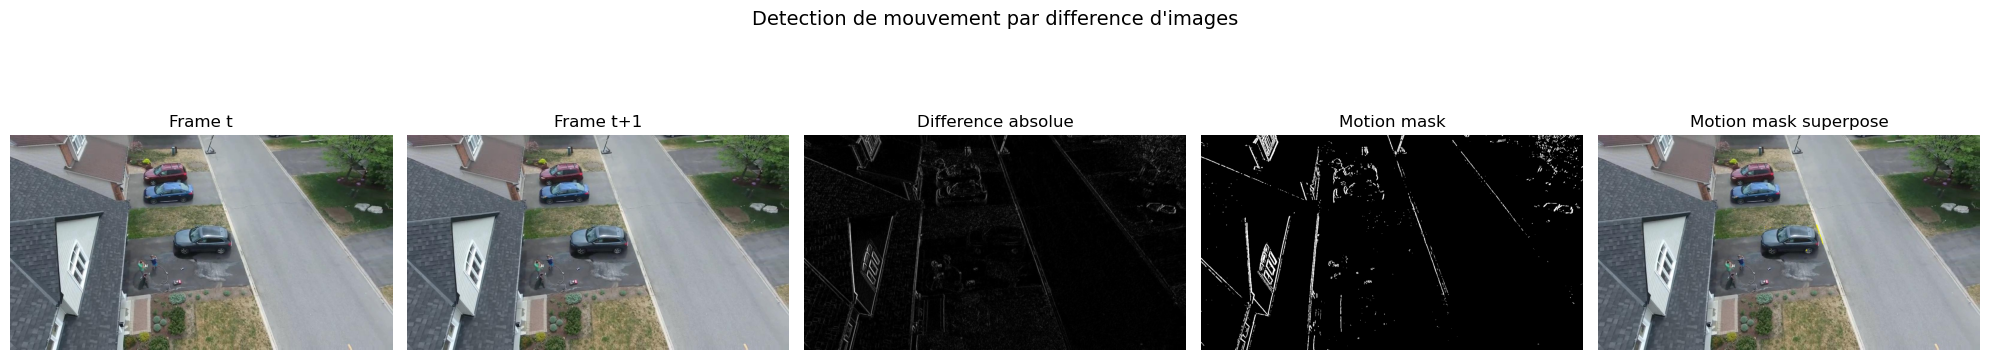

In [2]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def draw_bbox_local(image, bbox, color=(0, 255, 0), thickness=2):
    out = image.copy()
    x, y, w, h = [int(v) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out

def draw_points_local(image, points, color=(0, 0, 255)):
    out = image.copy()
    if points is None:
        return out
    for px, py in np.asarray(points).reshape(-1, 2):
        cv2.circle(out, (int(px), int(py)), 3, color, -1)
    return out

def draw_mask_overlay_local(frame, mask, bbox):
    out = frame.copy()
    overlay = out.copy()
    x, y, w, h = [int(v) for v in bbox]
    mask_roi = mask
    if mask_roi.shape[:2] != (h, w):
        mask_roi = cv2.resize(mask_roi, (w, h), interpolation=cv2.INTER_NEAREST)
    roi = overlay[y:y+h, x:x+w]
    roi[mask_roi > 0] = (0, 255, 0)
    overlay[y:y+h, x:x+w] = roi
    return cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

from src.preprocessing import preprocess_image_with_method
from src.motion_detection import detect_motion_between_frames, motion_detection_on_roi, overlay_motion_mask

motion_dir = ensure_dir(RESULTS_DIR / "motion_detection")
frame_t = cv2.imread(str(image_files[0]))
frame_tp1 = cv2.imread(str(image_files[1]))
gray_t = preprocess_image_with_method(frame_t, method="stretching")["enhanced"]
gray_tp1 = preprocess_image_with_method(frame_tp1, method="stretching")["enhanced"]
full_motion = detect_motion_between_frames(gray_t, gray_tp1, threshold=25)
roi_motion = motion_detection_on_roi(gray_t, gray_tp1, initial_bbox, threshold=25)
motion_overlay = overlay_motion_mask(frame_tp1, roi_motion["motion_mask"], bbox=initial_bbox)

save_bgr(motion_dir / "frame_t.png", frame_t)
save_bgr(motion_dir / "frame_t_plus_1.png", frame_tp1)
save_gray(motion_dir / "absolute_difference.png", full_motion["difference"])
save_gray(motion_dir / "motion_mask.png", full_motion["motion_mask"])
save_bgr(motion_dir / "motion_mask_overlay.png", motion_overlay)

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
items = [("Frame t", frame_t, False), ("Frame t+1", frame_tp1, False), ("Difference absolue", full_motion["difference"], True), ("Motion mask", full_motion["motion_mask"], True), ("Motion mask superpose", motion_overlay, False)]
for ax, (title, image, gray_mode) in zip(axes, items):
    ax.imshow(image if gray_mode else bgr_to_rgb(image), cmap="gray" if gray_mode else None)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Detection de mouvement par difference d'images", fontsize=14)
fig.tight_layout()
fig.savefig(motion_dir / "motion_detection_grid.png", dpi=150)
plt.show()


## Interpretation

La difference d'images fait ressortir les regions qui changent entre deux frames. Lorsque la zone active correspond a la voiture ou a ses contours, elle confirme le mouvement observe. Cette methode reste sensible aux variations d'eclairage, aux ombres et aux changements d'intensite qui ne sont pas toujours dus au mouvement de l'objet.


## Resume de l'etape

Canny valide visuellement les contours de la voiture, tandis que la difference d'images met en evidence les pixels mobiles. Ces deux observations preparent l'etape centrale: l'estimation du champ de mouvement par Lucas-Kanade.
